<a href="https://colab.research.google.com/github/rikaahire/cfpb-admin-effects/blob/main/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

credit_reporting_variants = [
    'Credit reporting',
    'Credit reporting or other personal consumer reports',
    'Credit reporting, credit repair services, or other personal consumer reports'
]

payday_variants = [
    'Payday loan',
    'Payday loan, title loan, or personal loan',
    'Payday loan, title loan, personal loan, or advance loan'
]

bank_variants = [
    'Bank account or service',
    'Checking or savings account'
]

credit_card_variants = [
    'Credit card',
    'Credit card or prepaid card',
    'Prepaid card'
]

money_transfer_variants = [
    'Money transfers',
    'Virtual currency',
    'Money transfer, virtual currency, or money service'
]

company_response_variants = [
    'Closed',
    'Closed with explanation'
]

referral_variants = [
    'Referral',
    'Web Referral'
]

manual_variants = [
    'Email',
    'Fax',
    'Postal mail'
]

needed_cols = [
    'Date received',
    'Date sent to company',
    'Product',
    'Submitted via',
    'Company response to consumer',
    'Timely response?',
    'ZIP code'
]

start_date = pd.to_datetime('2021-01-20')

print("Processing in chunks to save RAM...")

chunks = []
for chunk in pd.read_csv(url,
                         compression='zip',
                         usecols=needed_cols,
                         chunksize=100000,
                         low_memory=False):
    chunk['Product'] = chunk['Product'].replace(credit_reporting_variants, 'Credit Reporting')
    chunk['Product'] = chunk['Product'].replace(payday_variants, 'Payday Loan')
    chunk['Product'] = chunk['Product'].replace(bank_variants, 'Bank Account or Service')
    chunk['Product'] = chunk['Product'].replace(credit_card_variants, 'Credit Card or Prepaid Card')
    chunk['Product'] = chunk['Product'].replace(money_transfer_variants, 'Money Transfer, Virtual Currency, or Money Service')
    chunk['Company response to consumer'] = chunk['Company response to consumer'].replace(company_response_variants, 'Closed with Explanation')
    chunk['Submitted via'] = chunk['Submitted via'].replace(manual_variants, 'Email, Fax, or Postal Mail')
    chunk['Submitted via'] = chunk['Submitted via'].replace(referral_variants, 'Referral')
    chunk['Date received'] = pd.to_datetime(chunk['Date received'])
    filtered_chunk = chunk[chunk['Date received'] >= start_date]

    chunks.append(filtered_chunk)

df = pd.concat(chunks, ignore_index=True)

print(f"Success! Dataframe loaded with {len(df):,} rows.")
print(f"Date range: {df['Date received'].min().date()} to {df['Date received'].max().date()}")

df.head()

Processing in chunks to save RAM...
Success! Dataframe loaded with 13,109,869 rows.
Date range: 2021-01-20 to 2026-05-09


,Date received,Product,ZIP code,Submitted via,Date sent to company,Company response to consumer,Timely response?
0,2024-01-05,Credit Reporting,60502,Web,2024-01-05,Closed with non-monetary relief,Yes
1,2024-01-21,Credit Reporting,27401,Web,2024-01-21,Closed with Explanation,Yes
2,2024-01-23,Credit Reporting,46222,Web,2024-01-23,Closed with Explanation,Yes
3,2024-01-29,Credit Reporting,60411,Web,2024-01-29,Closed with non-monetary relief,Yes
4,2026-04-24,Bank Account or Service,34221,Web,2026-04-24,Closed with Explanation,Yes


In [2]:
df.shape

(13109869, 7)

In [3]:
new_names = {'Date received': 'date_received', 'Product': 'product', 'Submitted via':'submitted_via', 'Date sent to company':'date_sent_to_company', 'Company response to consumer':'company_response_to_consumer', 'Timely response?':'timely_response', 'ZIP code':'zip_code'}
df = df.rename(columns=new_names)
df = df[df['company_response_to_consumer'] != 'In progress']
categorical_cols = ['product', 'submitted_via', 'company_response_to_consumer', 'timely_response', 'zip_code']
df = df[~df['zip_code'].astype(str).str.contains('X')]
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [4]:
fraction_similar = (((df['date_received'] == df['date_sent_to_company']).sum())/df.shape[0])
print(f"Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: {fraction_similar:.2%}")

Similarity between the date the CFPB received the complaint and the date the CFPB sent the complaint to the company: 96.29%


In [5]:
!pip install census us
from census import Census
from us import states
import time

c = Census("1e55abc84d703c5a4403570935082050f58fb16a")

# Fetch specific variables for all ZCTAs (ZIP Codes)
# B19013_001E = Median Household Income
# B01003_001E = Total Population
# B15003_022E = Bachelor's Degree
# B03002_003E = % White (non-Hispanic)
# B03002_012E = % Hispanic or Latino
# B01002_001E = Median Age

variables = (
    'NAME',
    'B19013_001E', # Median Income
    'B01003_001E', # Total Pop
    'B15003_022E', # Bachelor's Degree
    'B03002_003E', # White
    'B03002_012E', # Hispanic
    'B02001_003E', # Black
    'B01002_001E',  # Median Age
    'B23025_003E', # Civilian Labor Force
    'B23025_005E', # Unemployed Count
    'B25003_001E', # Total Housing Units
    'B25003_002E'  # Owner Occupied Units
)

max_retries = 3
for i in range(max_retries):
    try:
        data = c.acs5.get(variables, {'for': 'zip code tabulation area:*'})
        break # Success!
    except Exception as e:
        print(f"Attempt {i+1} failed: {e}")
        if i < max_retries - 1:
            time.sleep(5) # Wait before trying again
        else:
            raise e

# Convert to DataFrame
census_df = pd.DataFrame(data)
census_df.rename(columns={
    'B19013_001E': 'median_income',
    'B01003_001E': 'total_population',
    'B15003_022E': 'bachelor_degree',
    'B03002_003E': 'white',
    'B03002_012E': 'hispanic_or_latino',
    'B02001_003E': 'black',
    'B01002_001E': 'median_age',
    'B23025_003E': 'labor_force',
    'B23025_005E': 'unemployed_count',
    'B25003_001E': 'total_units',
    'B25003_002E': 'owner_occupied',
    'zip code tabulation area': 'zip_code'
}, inplace=True)
# 4. Calculate all percentages
# Adding epsilon 1e-6 to avoid division by zero
pop = census_df['total_population'] + 1e-6

census_df['percent_black'] = census_df['black'] / pop
census_df['percent_hispanic'] = census_df['hispanic_or_latino'] / pop
census_df['percent_white'] = census_df['white'] / pop
census_df['percent_bachelors'] = census_df['bachelor_degree'] / pop

census_df['percent_unemployed'] = census_df['unemployed_count'] / (census_df['labor_force'] + 1e-6)
census_df['homeownership_rate'] = census_df['owner_occupied'] / (census_df['total_units'] + 1e-6)

# 5. Final Selection
census_df = census_df[[
    'zip_code', 'median_income', 'total_population',
    'median_age', 'percent_white', 'percent_black',
    'percent_hispanic', 'percent_bachelors', 'percent_unemployed', 'homeownership_rate'
]]

census_df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.8 MB/s eta 0:00:00


,zip_code,median_income,total_population,median_age,percent_white,percent_black,percent_hispanic,percent_bachelors,percent_unemployed,homeownership_rate
0,00601,19454.0,16669.0,45.3,0.003899,0.014458,0.993101,0.107265,0.205479,0.674584
1,00602,21420.0,37233.0,46.6,0.015470,0.018022,0.972390,0.141058,0.051337,0.735603
2,00603,20933.0,48448.0,46.1,0.010940,0.033273,0.984334,0.138375,0.153543,0.572798
3,00606,20992.0,5163.0,47.9,0.000968,0.001356,0.996707,0.071083,0.000000,0.795161
4,00610,24496.0,25357.0,45.7,0.015420,0.018930,0.964428,0.127144,0.060410,0.716264


In [6]:
missing_values = df.isnull().sum()

missing_values_percentage = (missing_values / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
zip_code,2500,0.021549
company_response_to_consumer,17,0.000147
date_received,0,0.000000
product,0,0.000000
submitted_via,0,0.000000
date_sent_to_company,0,0.000000
timely_response,0,0.000000


In [7]:
df.dropna(inplace=True)
df.head()

,date_received,product,zip_code,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response
0,2024-01-05,Credit Reporting,60502,Web,2024-01-05,Closed with non-monetary relief,Yes
1,2024-01-21,Credit Reporting,27401,Web,2024-01-21,Closed with Explanation,Yes
2,2024-01-23,Credit Reporting,46222,Web,2024-01-23,Closed with Explanation,Yes
3,2024-01-29,Credit Reporting,60411,Web,2024-01-29,Closed with non-monetary relief,Yes
4,2026-04-24,Bank Account or Service,34221,Web,2026-04-24,Closed with Explanation,Yes


In [8]:
missing_values = census_df.isnull().sum()

missing_values_percentage = (missing_values / len(census_df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_values_percentage})
missing_data.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
zip_code,0,0.0
median_income,0,0.0
total_population,0,0.0
median_age,0,0.0
percent_white,0,0.0
percent_black,0,0.0
percent_hispanic,0,0.0
percent_bachelors,0,0.0
percent_unemployed,0,0.0
homeownership_rate,0,0.0


In [9]:
# https://cfpb.github.io/api/ccdb/fields.html
df.drop('date_sent_to_company', axis = 1, inplace = True)
df['date_received'] = pd.to_datetime(df['date_received'])
df.head()

,date_received,product,zip_code,submitted_via,company_response_to_consumer,timely_response
0,2024-01-05,Credit Reporting,60502,Web,Closed with non-monetary relief,Yes
1,2024-01-21,Credit Reporting,27401,Web,Closed with Explanation,Yes
2,2024-01-23,Credit Reporting,46222,Web,Closed with Explanation,Yes
3,2024-01-29,Credit Reporting,60411,Web,Closed with non-monetary relief,Yes
4,2026-04-24,Bank Account or Service,34221,Web,Closed with Explanation,Yes


In [10]:
bins = [
    pd.Timestamp('2021-01-20'),
    pd.Timestamp('2025-01-20'),
    pd.Timestamp('2029-01-20')
]

labels = ['Biden', 'Trump_Two']

df['president_date_received'] = pd.cut(df['date_received'], bins=bins, labels=labels, right=False, ordered=False)
df.drop('date_received', axis = 1, inplace = True)

To prevent identifying individuals in sparsely populated areas, the CFPB only publishes the ZIP code if the Census Tabulation Area associated with it has at least 20,000 residents.

If a consumer lives in a small town or a rural area with fewer than 20,000 people, the database automatically masks their ZIP code as "XXXXX" to ensure their complaint cannot be traced back to their household.

In [11]:
# Ensure zip codes are strings and formatted the same way (5 digits)
census_df['zip_code'] = census_df['zip_code'].astype(str).str.zfill(5)
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)

# Merge with complaints data
# 'left' join preserves all complaints even if a zip isn't in the census file
df = df.merge(census_df, on='zip_code', how='inner')
df.drop(['zip_code'], axis = 1, inplace = True)
df.head()

,product,submitted_via,company_response_to_consumer,timely_response,president_date_received,median_income,total_population,median_age,percent_white,percent_black,percent_hispanic,percent_bachelors,percent_unemployed,homeownership_rate
0,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden,156904.0,23308.0,39.1,0.472971,0.076369,0.110005,0.246182,0.047394,0.785739
1,Credit Reporting,Web,Closed with Explanation,Yes,Biden,47972.0,21920.0,29.0,0.266560,0.607117,0.073723,0.110219,0.066339,0.364471
2,Credit Reporting,Web,Closed with Explanation,Yes,Biden,50783.0,38887.0,31.4,0.295317,0.267107,0.373672,0.072801,0.090162,0.482769
3,Credit Reporting,Web,Closed with non-monetary relief,Yes,Biden,62073.0,52175.0,35.5,0.194633,0.496119,0.257614,0.094279,0.116404,0.652333
4,Bank Account or Service,Web,Closed with Explanation,Yes,Trump_Two,77712.0,56208.0,45.5,0.609362,0.128914,0.205131,0.148128,0.038595,0.828708


In [12]:
df.shape

(11526231, 14)

In [13]:
df['president_date_received'].value_counts()

,count
president_date_received,
Trump_Two,6516822
Biden,5009409


In [14]:
df['product'].value_counts()

,count
product,
Credit Reporting,9993963
Debt collection,650662
Credit Card or Prepaid Card,279782
Bank Account or Service,228729
"Money Transfer, Virtual Currency, or Money Service",117266
Mortgage,101786
Vehicle loan or lease,58173
Student loan,53260
Payday Loan,35943


In [15]:
df['submitted_via'].value_counts()

,count
submitted_via,
Web,11331283
Phone,100804
Referral,65106
"Email, Fax, or Postal Mail",29038


In [16]:
df['company_response_to_consumer'].value_counts()

,count
company_response_to_consumer,
Closed with Explanation,6788663
Closed with non-monetary relief,4630684
Closed with monetary relief,89570
Untimely response,17314


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11526231 entries, 0 to 11526230
Data columns (total 14 columns):
 #   Column                        Dtype   
---  ------                        -----   
 0   product                       category
 1   submitted_via                 category
 2   company_response_to_consumer  category
 3   timely_response               category
 4   president_date_received       category
 5   median_income                 float64 
 6   total_population              float64 
 7   median_age                    float64 
 8   percent_white                 float64 
 9   percent_black                 float64 
 10  percent_hispanic              float64 
 11  percent_bachelors             float64 
 12  percent_unemployed            float64 
 13  homeownership_rate            float64 
dtypes: category(5), float64(9)
memory usage: 846.4 MB


In [18]:
df.describe(include='all')

,product,submitted_via,company_response_to_consumer,timely_response,president_date_received,median_income,total_population,median_age,percent_white,percent_black,percent_hispanic,percent_bachelors,percent_unemployed,homeownership_rate
count,11526231,11526231,11526231,11526231,11526231,1.152623e+07,1.152623e+07,1.152623e+07,1.152623e+07,1.152623e+07,1.152623e+07,1.152623e+07,1.152623e+07,1.152623e+07
unique,10,4,4,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Credit Reporting,Web,Closed with Explanation,Yes,Trump_Two,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,9993963,11331283,6788663,11477066,6516822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,-5.433303e+05,4.148844e+04,-1.203832e+05,3.823107e-01,2.643153e-01,2.500862e-01,1.431137e-01,6.366796e-02,5.948419e-01
std,NaN,NaN,NaN,NaN,NaN,2.038945e+07,2.121503e+04,8.959139e+06,2.441623e-01,2.450737e-01,2.244638e-01,6.516727e-02,3.112172e-02,1.822091e-01
min,NaN,NaN,NaN,NaN,NaN,-6.666667e+08,0.000000e+00,-6.666667e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,5.989100e+04,2.676100e+04,3.470000e+01,1.737816e-01,6.981212e-02,7.669557e-02,9.484536e-02,4.262184e-02,4.846300e-01
50%,NaN,NaN,NaN,NaN,NaN,7.531900e+04,3.887200e+04,3.740000e+01,3.659706e-01,1.759444e-01,1.748627e-01,1.341277e-01,5.736800e-02,6.152187e-01
75%,NaN,NaN,NaN,NaN,NaN,9.686600e+04,5.367100e+04,4.040000e+01,5.738366e-01,3.994966e-01,3.590134e-01,1.827755e-01,7.685275e-02,7.304404e-01


In [19]:
df.dropna(inplace=True)
print(df.isnull().sum())

product                         0
submitted_via                   0
company_response_to_consumer    0
timely_response                 0
president_date_received         0
median_income                   0
total_population                0
median_age                      0
percent_white                   0
percent_black                   0
percent_hispanic                0
percent_bachelors               0
percent_unemployed              0
homeownership_rate              0
dtype: int64


In [20]:
df['product'].value_counts()

,count
product,
Credit Reporting,9993963
Debt collection,650662
Credit Card or Prepaid Card,279782
Bank Account or Service,228729
"Money Transfer, Virtual Currency, or Money Service",117266
Mortgage,101786
Vehicle loan or lease,58173
Student loan,53260
Payday Loan,35943


In [21]:
df['president_date_received'].value_counts()

,count
president_date_received,
Trump_Two,6516822
Biden,5009409


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack

ohe_cols = ['product', 'submitted_via', 'company_response_to_consumer',
       'timely_response']
encoder = OneHotEncoder(sparse_output=True, drop='first')
X_sparse = encoder.fit_transform(df[ohe_cols])

In [21]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# 1. Scale the numerical variables
# We convert them to a 2D array for the scaler
scaler = StandardScaler()
num_cols = ['median_income', 'total_population', 'median_age', 'percent_white', 'percent_black', 'percent_hispanic', 'percent_bachelors', 'percent_unemployed', 'homeownership_rate']
X_scaled_num = scaler.fit_transform(df[num_cols])

# 2. Convert the scaled numbers to a sparse matrix
# This keeps the math consistent for hstack
X_scaled_num_sparse = csr_matrix(X_scaled_num)

# 3. Combine with One-Hot Encoded features
# X_sparse is categorical data
X_final = hstack([X_scaled_num_sparse, X_sparse])

# 4. Update feature names list for the Logistic Regression coefficients
feature_names = num_cols + list(encoder.get_feature_names_out(ohe_cols))

print(f"Final feature count: {len(feature_names)}")
print(feature_names)

Final feature count: 25
['median_income', 'total_population', 'median_age', 'percent_white', 'percent_black', 'percent_hispanic', 'percent_bachelors', 'percent_unemployed', 'homeownership_rate', 'product_Credit Card or Prepaid Card', 'product_Credit Reporting', 'product_Debt collection', 'product_Debt or credit management', 'product_Money Transfer, Virtual Currency, or Money Service', 'product_Mortgage', 'product_Payday Loan', 'product_Student loan', 'product_Vehicle loan or lease', 'submitted_via_Phone', 'submitted_via_Referral', 'submitted_via_Web', 'company_response_to_consumer_Closed with monetary relief', 'company_response_to_consumer_Closed with non-monetary relief', 'company_response_to_consumer_Untimely response', 'timely_response_Yes']


In [22]:
y = df['president_date_received']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.2,
    random_state=5,
    stratify=y
)
import gc
del X_sparse
del X_scaled_num_sparse
del X_final
del df
gc.collect()

0

In [23]:
# Standardize the sparse data (Mean 0, Std 1) for correlation
from sklearn.preprocessing import MaxAbsScaler
import numpy as np
sample_size = 20000
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_sparse = X_train[indices]

X_scaled = MaxAbsScaler().fit_transform(X_sample_sparse)

# 4. Sparse multiplication
n_samples = X_sample_sparse.shape[0]
# Use .tocsr() to ensure efficient multiplication
covariance_matrix = (X_scaled.T.tocsr() @ X_scaled.tocsr()) / (n_samples - 1)

# 5. Convert to DataFrame (now safe because we reduced features)
corr_matrix_dense = covariance_matrix.toarray()
corr_df = pd.DataFrame(corr_matrix_dense, columns=feature_names, index=feature_names)

# 6. Unstack and filter
corr_pairs = corr_df.unstack()
highly_correlated_pairs = corr_pairs[
    (corr_pairs >= 0.7) & (corr_pairs < 1.0)
].sort_values(ascending=False)

print(highly_correlated_pairs)

timely_response_Yes       timely_response_Yes         0.995000
submitted_via_Web         submitted_via_Web           0.982049
                          timely_response_Yes         0.977199
timely_response_Yes       submitted_via_Web           0.977199
product_Credit Reporting  product_Credit Reporting    0.864243
                          timely_response_Yes         0.863143
timely_response_Yes       product_Credit Reporting    0.863143
submitted_via_Web         product_Credit Reporting    0.858743
product_Credit Reporting  submitted_via_Web           0.858743
dtype: float64


Pearson correlation requires the data to be centered (mean = 0). However, centering sparse data turns every 0 into a non-zero number, which would immediately crash the RAM by making the matrix dense. As a result, while MaxAbsScaler doesn't center the data, the resulting "correlation" matrix is still helpful for identifying redundancy. If two features have a score of 0.9 in this matrix, they are highly collinear, and one should be dropped, even if it's not exactly Pearson correlation.

product_Credit Reporting: Over 70% of all complaints in recent years are about Credit Reporting, so it may be the feature the model depends on to distinguish between administrations since the amount of complaints in this category may have changed over time.

submitted_via_Web: Most people disputing credit report errors do so online. As a result, it may have a similar distribution in the data as product_Credit Reporting but may provide less insight on regulatory enforcement.


timely_response_Yes: While this provides information on company performance, it is something that happens after the complaint is filed so may correlate with how the complaint is submitted or with the product type.

In [24]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
# source: https://www.statology.org/cramers-v-in-python/

# Find the index of the column to drop
col_to_drop = 'submitted_via_Web'
drop_idx = feature_names.index(col_to_drop)

print(f"Index of '{col_to_drop}': {drop_idx}")

# Create a list of all indices except the one we want to drop
keep_indices = [i for i in range(len(feature_names)) if i != drop_idx]

# Slice the sparse matrices
X_train = X_train[:, keep_indices]
X_test = X_test[:, keep_indices]

# Update feature names list to keep track of what's left
feature_names = [feature_names[i] for i in keep_indices]

print(f"New shape: {X_train.shape}")

# Find the index of the column to drop
col_to_drop = 'timely_response_Yes'
drop_idx = feature_names.index(col_to_drop)

print(f"Index of '{col_to_drop}': {drop_idx}")

# Create a list of all indices except the one we want to drop
keep_indices = [i for i in range(len(feature_names)) if i != drop_idx]

# Slice the sparse matrices
X_train = X_train[:, keep_indices]
X_test = X_test[:, keep_indices]

# Update feature names list to keep track of what's left
feature_names = [feature_names[i] for i in keep_indices]

print(f"New shape: {X_train.shape}")

Index of 'submitted_via_Web': 20
New shape: (9211204, 24)
Index of 'timely_response_Yes': 23
New shape: (9211204, 23)


In [25]:
# https://www.geeksforgeeks.org/python/detecting-multicollinearity-with-vif-python/
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_df = pd.DataFrame(X_train[indices].toarray(), columns=feature_names)
vif_data = add_constant(X_sample_df)

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                                              Feature       VIF
4                                       percent_white  9.652908
5                                       percent_black  9.004173
6                                    percent_hispanic  7.946797
11                           product_Credit Reporting  6.814101
12                            product_Debt collection  3.983750
10                product_Credit Card or Prepaid Card  2.213992
8                                  percent_unemployed  1.788209
7                                   percent_bachelors  1.720415
14  product_Money Transfer, Virtual Currency, or M...  1.541616
15                                   product_Mortgage  1.436346
9                                  homeownership_rate  1.341169
17                               product_Student loan  1.294758
18                      product_Vehicle loan or lease  1.280461
3                                          median_age  1.210715
1                                       

In [26]:
# https://stackoverflow.com/questions/29294983/how-to-calculate-correlation-between-all-columns-and-remove-highly-correlated-on
# source: https://www.statology.org/cramers-v-in-python/

# Find the index of the column to drop
col_to_drop = 'percent_white'
drop_idx = feature_names.index(col_to_drop)

print(f"Index of '{col_to_drop}': {drop_idx}")

# Create a list of all indices except the one we want to drop
keep_indices = [i for i in range(len(feature_names)) if i != drop_idx]

# Slice the sparse matrices
X_train = X_train[:, keep_indices]
X_test = X_test[:, keep_indices]

# Update feature names list to keep track of what's left
feature_names = [feature_names[i] for i in keep_indices]

print(f"New shape: {X_train.shape}")

Index of 'percent_white': 3
New shape: (9211204, 22)


VIF < 5: very little multicollinearity, and model coefficients should be reliable


VIF 5–10: Moderate correlation, but usually acceptable for most models


VIF > 10: a lot of multicollinearity


product_Credit Reporting has the highest VIF (6.6) since it is the most seen category in the dataset. Since we are using Logistic Regression, we want to keep features that have a strong relationship with the target. Credit Reporting might be the most important predictor. If we drop it, our model's accuracy might drop since this feature might be the one with the most information for the model.

To lower the VIF and make our model stable, we drop percent_white so percent_white is the reference category. Since in US political modeling the standard practice is to use the majority population as the reference and then understand how changes in the minority populations change predictions.

In [27]:
sample_size = min(100000, X_train.shape[0])
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample_df = pd.DataFrame(X_train[indices].toarray(), columns=feature_names)
vif_data = add_constant(X_sample_df)

vif_series = pd.DataFrame()
vif_series["Feature"] = vif_data.columns
vif_series["VIF"] = [variance_inflation_factor(vif_data.values, i)
                     for i in range(vif_data.shape[1])]

print(vif_series[vif_series['Feature'] != 'const'].sort_values(by="VIF", ascending=False))

                                              Feature       VIF
10                           product_Credit Reporting  6.858541
11                            product_Debt collection  3.985053
9                 product_Credit Card or Prepaid Card  2.221479
4                                       percent_black  2.020684
5                                    percent_hispanic  1.824808
7                                  percent_unemployed  1.775013
6                                   percent_bachelors  1.636897
13  product_Money Transfer, Virtual Currency, or M...  1.547492
14                                   product_Mortgage  1.441095
8                                  homeownership_rate  1.323675
16                               product_Student loan  1.292024
17                      product_Vehicle loan or lease  1.266289
15                                product_Payday Loan  1.168963
1                                       median_income  1.159553
3                                       

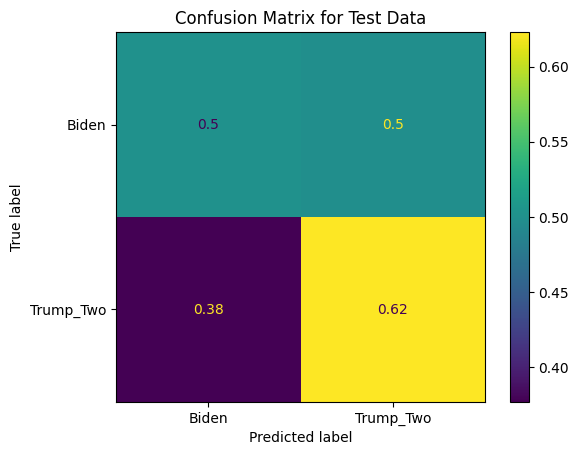

Test Set Balanced Accuracy: 0.5619774233356987


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt

lr = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=5).fit(X_train, y_train)
predictions = lr.predict(X_test)
cm = confusion_matrix(y_test, predictions, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
plt.title('Confusion Matrix for Test Data')
plt.show()
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test, predictions))

In [29]:
# 1. Create the DataFrame using only the first (and only) row of coefficients
# We use lr.classes_[1] because the coefficients usually correspond to the "positive" class (class 1)
coef_df = pd.DataFrame(
    lr.coef_[0],
    index=feature_names,
    columns=['Coefficient']
)

# 2. Add an Odds Ratio column for easier interpretation
coef_df['Odds_Ratio'] = np.exp(coef_df['Coefficient'])

# 3. Sort to see which features favor which administration
# Higher Odds Ratio (>1) favors the "Positive" class (usually lr.classes_[1])
# Lower Odds Ratio (<1) favors the "Negative" class (usually lr.classes_[0])
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(f"Model classes: {lr.classes_}")
print(f"Positive coefficients favor: {lr.classes_[1]}")
print(f"Negative coefficients favor: {lr.classes_[0]}")

display(coef_df)

Model classes: ['Biden' 'Trump_Two']
Positive coefficients favor: Trump_Two
Negative coefficients favor: Biden


,Coefficient,Odds_Ratio
company_response_to_consumer_Untimely response,1.554633,4.733349
product_Credit Reporting,0.877666,2.405278
product_Debt or credit management,0.597427,1.817436
product_Debt collection,0.537185,1.711183
product_Payday Loan,0.108510,1.114616
percent_hispanic,0.081654,1.085081
homeownership_rate,0.055291,1.056848
"product_Money Transfer, Virtual Currency, or Money Service",0.044746,1.045762
product_Vehicle loan or lease,0.044488,1.045492
product_Credit Card or Prepaid Card,0.032087,1.032608


Positive Coefficients / Odds Ratio > 1: As this feature increases, the complaint is more likely to be from the Trump_Two era.

Negative Coefficients / Odds Ratio < 1: As this feature increases, the complaint is more likely to be from the Biden era.

If median_income has an Odds Ratio of 1.15, it means that for every 1-unit increase in standardized income, the odds of the complaint belonging to the Trump era increase by 15%.If product_Student loan has an Odds Ratio of 0.60, it means that feature is associated with the Biden era (since $0.60 < 1.0$).

The strongest predictor for the Trump_Two administration is that the company responded to the consumer complaint in an untimely manner. Untimely response means that the company did not respond to the consumer complaint on time. Based on the model's odd ratio, a complaint is 4.6 times more likely to be from the current Trump administration if the company did not respond on time. This could imply a change in regulatory pressure for companies to respond to consumers or a shift in how companies regard the CFPB's deadlines.

In terms of products, credit reporting and debt are some of the model's top predictors. A complaint about credit reporting is 2.4 times as likely in the current administration and a complaint about debt management is 1.71 times as likely in the current administration.

In terms of demographic features, complaints from a ZIP code with a higher percentage of Hispanics or Latinos and/or a ZIP code with higher rates of homeownership are more likely to be during the Trump administration.

On the other hand, the features that have almost zero predictive power for the model are median income and median age. This means that complaints are more driven by the product rather than the age or income of a person.

The main changes between administrations is characterized by a drop in company responsiveness (corresponding to the higher probability of seeing an untimely response to consumer complaints), a change in the product that is the focus of consumer complaints (products during the Biden administration tended to be more interest related, such as mortgage and student loan, while products during the Trump administration tended to be more credit driven, such as credit reporting and debt/credit management), and a change in how consumers interact with the CFPB (Biden's administration saw more complaints submitted via referral and via phone compared to the Trump administration).

Choice for Logistic Regression:
- Fast to train
- Better results than Decision Tree classifier, which overpredicts second Trump administration for consumer complaints during the Biden administration
- almost identical accuracy as LinearSVC, except Logistic Regression results are more interpretable since it is designed for Odds Ratios

The model is only performing about 6% better than random chance.

The data suggests that there is a lack of distinct patterns in the features.

Consumers tend to complain about the same products regardless of the administration. Credit reporting consists of 77% of all complaints. As a result, most complaint's product feature does not help the model distinguish between administrations.

Similarly, most complaints are submitted through the Web. Since the behavior of how people submit complaints does not change a lot when the administration changes, this feature does not have a lot of predictive power.

The ways companies respond appear to be standard industry practices that do not change based on who is in the White House.

As a result, the model does not perform much higher than random since the features do not capture any political or economic changes that define an administration.

To improve it might help to look at the Complaint Narrative feature to find specific policy-related language that changes between the administrations (this is done in the Topic Modeling section). It might also help to examine if consumer sentiment is a strong predictor of administration (this is done in the Sentiment and Severity Analysis section).

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Verify: Biden might be 0 and Trump_Two might be 1
print(f"Classes: {le.classes_}")

Classes: ['Biden' 'Trump_Two']


Iteration 1, loss = 0.66872973
Validation score: 0.592466
Iteration 2, loss = 0.66776198
Validation score: 0.592589
Iteration 3, loss = 0.66741356
Validation score: 0.593617
Iteration 4, loss = 0.66720448
Validation score: 0.593540
Iteration 5, loss = 0.66701791
Validation score: 0.593795
Iteration 6, loss = 0.66687313
Validation score: 0.593462
Iteration 7, loss = 0.66680356
Validation score: 0.593736
Iteration 8, loss = 0.66672296
Validation score: 0.594669
Iteration 9, loss = 0.66662720
Validation score: 0.593870
Iteration 10, loss = 0.66661624
Validation score: 0.592730


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


Test Set Balanced Accuracy: 0.5481663873662178


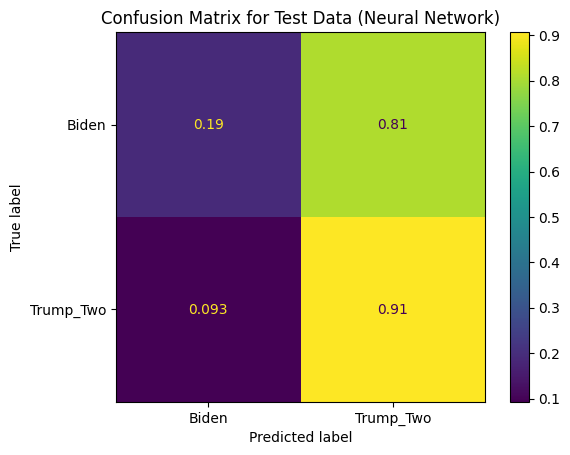

In [31]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.utils import resample

# Initialize the model
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',       # Standard for hidden layers
    solver='adam',           # Best for large datasets
    alpha=0.0001,            # L2 penalty to prevent overfitting
    batch_size=1024,         # Large batches for 11M rows
    learning_rate_init=0.01,
    max_iter=10,             # We use early stopping instead of many epochs
    early_stopping=True,     # CRITICAL: Stops training when validation score stalls
    validation_fraction=0.1, # Uses 10% of data to check for overfitting
    verbose=True,            # Shows progress
    random_state=5
)

# Train the model
mlp.fit(X_train, y_train_encoded)

# Evaluate
predictions = mlp.predict(X_test)
print('Test Set Balanced Accuracy:', balanced_accuracy_score(y_test_encoded, predictions))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_test_encoded, predictions, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("Confusion Matrix for Test Data (Neural Network)")
plt.show()

In [34]:
import numpy as np
from sklearn.inspection import permutation_importance

# 1. Take a sample that fits in RAM
# We need to do this because .toarray() on 2.3M rows will crash
sample_size = 10000
indices = np.random.choice(X_test.shape[0], sample_size, replace=False)

# Convert only the sample to a dense array
X_test_sample_dense = X_test[indices].toarray()
y_test_sample_encoded = y_test_encoded[indices]

# 2. Run permutation importance on the dense sample
print(f"Running permutation importance on {sample_size} rows...")
result = permutation_importance(
    mlp,
    X_test_sample_dense,
    y_test_sample_encoded,
    n_repeats=5,         # Reduced repeats slightly to save time
    random_state=5,
    n_jobs=-1
)

# 3. Create the DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': result.importances_mean,
    'Importance_Std': result.importances_std
}).sort_values(by='Importance_Mean', ascending=False)

print(importance_df)

Running permutation importance on 10000 rows...
                                              Feature  Importance_Mean  \
9                            product_Credit Reporting          0.03428   
4                                    percent_hispanic          0.00902   
3                                       percent_black          0.00604   
10                            product_Debt collection          0.00498   
5                                   percent_bachelors          0.00380   
20  company_response_to_consumer_Closed with non-m...          0.00300   
17                                submitted_via_Phone          0.00254   
6                                  percent_unemployed          0.00244   
7                                  homeownership_rate          0.00242   
19  company_response_to_consumer_Closed with monet...          0.00176   
18                             submitted_via_Referral          0.00156   
1                                    total_population          0

The neural network uses credit reporting as the product of a consumer complaint as its most important feature. The model's accuracy drops 3.4% when the entries in the column are shuffled. This implies that the model sees this feature as the main determinant for deciding which administration the CFPB received a consumer complaint in.

Three demographic features (percent Hispanic or Latino, percent Black, and percent with a Bachelor's degree) make up the model's top five most important predictors. This shows that the model is depending on the ZIP code demographics to determine if a consumer filed a complaint during the Biden or Trump administration.

In comparison to the Logistic Regression model, the Neural Network found the untimely response to not be characteristic of determining which administration the CFPB received a consumer complaint. This may happen since while the logistic regression model finds linear relationships, the neural network can find nonlinear relationships, possibly tying the untimely response to other predictors. Moreover, since the Neural Network tends to predict Trump, tying the untimely response to other features does not hurt its accuracy as much.

Here, median age, student loans, and payday loans have negative importance, meaning that shuffling these features increased the model's accuracy or had no effect on the model's accuracy. This highlights that these features are not important to the model in determining which administration the CFPB received a consumer complaint.

Compared to the Logistic Regression model, the Neural Network focuses more on who is complaining and what they are complaining about rather than how a company responds to the consumer.

Future studies could look into the possible relationship between the high importances of credit reporting and percent Hispanic or Latino since the Neural Network may have identified a relationship between the two.

In [35]:
feature_names

['median_income',
 'total_population',
 'median_age',
 'percent_black',
 'percent_hispanic',
 'percent_bachelors',
 'percent_unemployed',
 'homeownership_rate',
 'product_Credit Card or Prepaid Card',
 'product_Credit Reporting',
 'product_Debt collection',
 'product_Debt or credit management',
 'product_Money Transfer, Virtual Currency, or Money Service',
 'product_Mortgage',
 'product_Payday Loan',
 'product_Student loan',
 'product_Vehicle loan or lease',
 'submitted_via_Phone',
 'submitted_via_Referral',
 'company_response_to_consumer_Closed with monetary relief',
 'company_response_to_consumer_Closed with non-monetary relief',
 'company_response_to_consumer_Untimely response']

Features were selected to cover economic, social, and operational differences between the Biden and Trump administrations.

The features that convey socio-demographic information are: `median_income`, `total_population`, `median_age`, `percent_black`, `percent_hispanic`, `percent_bachelors`, `percent_unemployed`, `homeownership_rate`. These  are important since ___.

The features that convey financial product context are: `product_Mortgage`, `product_Credit Reporting`, `product_Student loan`. These are important since different administrations have different economic crises and these financial products may convey that. This is illustrated in the Logistic Regression model that found that during the Biden era, high interest rates made mortgage servicing a major point of friction and student loans was a central policy debate for Biden (forgiveness vs. court battles). Meanwhile, credit reporting is the current biggest product of the Trump era. I selected these to see if the topic of the complaint changes when the regulatory philosophy changes.

The features that convey company accountability and the CFPB operational behavior are `company_response_to_consumer_...` and `submitted_via_...`, which measure how companies behave under different regulatory enforcements. Untimely response is the most important predictor in the Logistic Regression model. It checks if the companies become more or less responsive when the administration changes. Monetary and non-monetary relief are included to check if one adminisstration results in consumers getting more money back than another. Finally, technological shifts are tracked using submission methods.

Variance inflation factor and correlation was used to remove redundant features, such as removing the percent of ZIP code that is white, to make sure that all the features employed in the model are mathematically independent.

I selected features from Census demographics and the CFPB consumer complaint database to test the hypothesis that the administration era can be predicted by who is complaining (demographics) and how companies are responding (regulatory environment). By merging local economic indicators with national complaint trends, the report successfuly finds features that distinguishes the consumer complaints by administration.